# 🎵 Music Genre Classification

This notebook presents a machine learning pipeline for classifying music genres using the **GTZAN dataset**.

We explore and compare the performance of the following models:

1. **Support Vector Machines (SVM)** trained on MFCC audio features.  
   We use an RBF (Gaussian) kernel and evaluate two multiclass strategies:  
   - *One-vs-Rest (OvR)*  
   - *One-vs-One (OvO)*

2. **Multilayer Perceptron (MLP)** trained on MFCC audio features.

3. **Convolutional Neural Network (CNN)** trained on mel spectrogram images.

### Import libraries, define configuration, and set random seeds for reproducibility

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import random
import sys
import os
import json

import torch
import torch.nn as nn
import torch.optim as optim

import courselib.utils.loaders as loaders
from courselib.utils.splits import train_test_split
from courselib.utils.splits import train_test_split_images
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from courselib.models.multiclass_svm import KernelMulticlassOvR
from courselib.models.multiclass_svm import KernelMulticlassOvO
from courselib.utils.metrics import confusion_matrix
from courselib.utils.preprocessing import labels_to_numbers
from courselib.utils.preprocessing import labels_encoding
from courselib.utils.preprocessing import one_hot_encoding
from courselib.models.nn import MLP
from courselib.optimizers import AdamOptimizer
from courselib.utils.metrics import accuracy
from courselib.utils.metrics import cross_entropy
from courselib.utils.metrics import plot_learning_curves
from courselib.models.cnn import SimpleCNN, load_SimpleCNN_model


# Add the repo root (two levels up from this notebook) to sys.path
sys.path.insert(0, os.path.abspath("../../"))

config = {
    "C": 1.0,
    "kernel": "rbf",
    "random_seed": 42,
    "training_data_fraction": 0.8,
    "layer_widths": [40, 128, 64, 10],
    "optimizer_learning_rate": 0.001,
    "activation": "ReLU",
    "output_activation": "Softmax",
    "loss": "CE",
    "epochs": 200,
    "batch_size": 128,
}

config_cnn = {
    "img_size": 128,
    "batch_size": 32,
    "data_path": "./data/spectrograms",
    "training_data_fraction": 0.8,
    "epochs": 25,
    "normalize_mean": [0.5, 0.5, 0.5],
    "normalize_std": [0.5, 0.5, 0.5],
    "learning_rate": 0.001,
    "dropout": 0.0,
    "num_classes": 10,
    "activation": "ReLU"
}

np.random.seed(config["random_seed"])
random.seed(config["random_seed"])
torch.manual_seed(config["random_seed"])

### Loading CSV Files for MFCC-Based Models

The GTZAN dataset provides audio features in two formats:

1. 30-second fragments — one per song  
2. 10 segments of 3 seconds each — created by splitting the 30-second clips

In this notebook, we use the 30-second fragments to make the models train and evaluate faster.

**Note**: The dataset must be downloaded manually in advance. There is no direct download link available — you must obtain the data (CSV files and spectrogram images) separately and place them in the appropriate `data/` folder.


In [2]:
df = loaders.load_music_30_sec()
#df = loaders.load_music_3_sec()

class_names = sorted(df["label"].unique().tolist())

Loading from `data/features_30_sec.csv`...


### Train-Test Split

We will train the SVM and MLP models on all MFCC features.  
The dataset is split into training and test sets using an **80/20** ratio.

In [3]:
# Extract only MFCC columns from df
mfcc_columns = [col for col in df.columns if col.startswith('mfcc')]
features = mfcc_columns + ['label']

# Do train test split
X, Y, X_train, Y_train, X_test, Y_test = train_test_split(
    df[features],
    training_data_fraction=config["training_data_fraction"],
    class_column_name='label',
    shuffle=True,
    return_numpy=True
)

print('Training data split as follows:')
print(f'  Training data samples: {len(X_train)}')
print(f'      Test data samples: {len(X_test)}')

Training data split as follows:
  Training data samples: 800
      Test data samples: 200


### Preprocessing

We standardize our features using **z-score normalization**. This step rescales all features to have zero mean and unit variance.

We also compute a reasonable value for the kernel width **parameter $\sigma$** using the *median heuristic*:
$$
\sigma = \sqrt{ \frac{ \text{median}( \| x_i - x_j \|^2 ) }{2} }
$$

This tunning was done because of low accuracy of the models on not preprocessed data.

In [4]:
# Standardize features (z-score)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

# Compute kernel width using median heuristic (for RBF kernel)
subset = X_train[np.random.choice(len(X_train), 500, replace=False)]
d2 = np.sum((subset[:, None, :] - subset[None, :, :])**2, axis=-1)
sigma = np.sqrt(0.5 * np.median(d2[d2 > 0]))  # avoid zero distances

### OvR model

First we train the One-vs-Rest classification strategy with the **RBF Binary Kernel SVM** model with the parameter $\sigma$ calculated in the previous cell.

In [5]:
svmOvR = KernelMulticlassOvR(kernel=config["kernel"], sigma=sigma, C=config["C"])
svmOvR.fit(X_train, Y_train)

### Evaluation Methods

The models are evaluated using the following metrics:

1. Train and Test Accuracy
2. Learning Curve  
3. Confusion Matrix  
4. Genre-wise Performance Analysis using `classification_report` from `sklearn.metrics`, which includes:
   - Precision: how many times the genre was correctly predicted, out of all the times the model predicted this genre. (This corresponds to the percentage within the column of the confusion matrix.)
   - Recall: how many times the genre was correctly predicted, out of all actual instances of that genre in the test set. (This corresponds to the percentage within the row of the confusion matrix.)
   - F1-score: harmonic mean of precision and recall
   - Support: how many times the genre appeared in the test set


🎯 Overall accuracy (OvR): 68.5000 %
📊 Accuracy of each binary model (One-vs-Rest):
  - Class 'blues': 91.0000
  - Class 'classical': 98.5000
  - Class 'country': 91.5000
  - Class 'disco': 91.0000
  - Class 'hiphop': 90.0000
  - Class 'jazz': 92.0000
  - Class 'metal': 97.5000
  - Class 'pop': 96.0000
  - Class 'reggae': 90.5000
  - Class 'rock': 94.5000


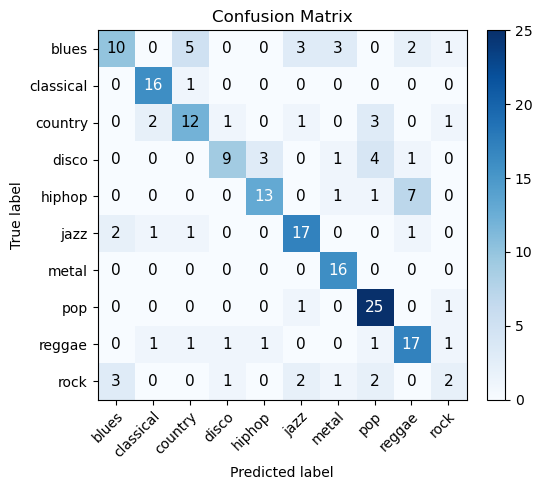

              precision    recall  f1-score   support

       blues       0.67      0.42      0.51        24
   classical       0.80      0.94      0.86        17
     country       0.60      0.60      0.60        20
       disco       0.75      0.50      0.60        18
      hiphop       0.76      0.59      0.67        22
        jazz       0.71      0.77      0.74        22
       metal       0.73      1.00      0.84        16
         pop       0.69      0.93      0.79        27
      reggae       0.61      0.74      0.67        23
        rock       0.33      0.18      0.24        11

    accuracy                           0.69       200
   macro avg       0.67      0.67      0.65       200
weighted avg       0.68      0.69      0.67       200



In [6]:
svmOvR.evaluate_accuracy(X_test, Y_test)
svmOvR.evaluate_models(X_test, Y_test)

true_labels = labels_encoding(Y_test, labels=class_names, pos_value=1, neg_value= 0)
pred_labels = labels_encoding(svmOvR(X_test), labels=class_names, pos_value=1, neg_value= 0)

confusion_matrix(true_labels, pred_labels, num_classes=10, class_names=class_names)

print(classification_report(Y_test, svmOvR(X_test), target_names=class_names))

### OvO model

Then we train the One-vs-One classification strategy with the **RBF Binary Kernel SVM** model with the parameter $\sigma$ calculated in the previous cell.

Then evaluate the performance over the test data. Both single model as well as overall performance statistics are calculated.

In [7]:
svmOvO = KernelMulticlassOvO(kernel=config["kernel"], sigma=sigma, C=config["C"])
svmOvO.fit(X_train, Y_train)

🎯 Overall accuracy (OvO): 71.0000 %
📊 Accuracy of each OvO binary classifier:
  - Classifier 'blues' vs 'classical': 97.5610
  - Classifier 'blues' vs 'country': 81.8182
  - Classifier 'blues' vs 'disco': 100.0000
  - Classifier 'blues' vs 'hiphop': 97.8261
  - Classifier 'blues' vs 'jazz': 89.1304
  - Classifier 'blues' vs 'metal': 92.5000
  - Classifier 'blues' vs 'pop': 100.0000
  - Classifier 'blues' vs 'reggae': 91.4894
  - Classifier 'blues' vs 'rock': 85.7143
  - Classifier 'classical' vs 'country': 94.5946
  - Classifier 'classical' vs 'disco': 97.1429
  - Classifier 'classical' vs 'hiphop': 100.0000
  - Classifier 'classical' vs 'jazz': 89.7436
  - Classifier 'classical' vs 'metal': 100.0000
  - Classifier 'classical' vs 'pop': 100.0000
  - Classifier 'classical' vs 'reggae': 95.0000
  - Classifier 'classical' vs 'rock': 96.4286
  - Classifier 'country' vs 'disco': 84.2105
  - Classifier 'country' vs 'hiphop': 100.0000
  - Classifier 'country' vs 'jazz': 88.0952
  - Classifier

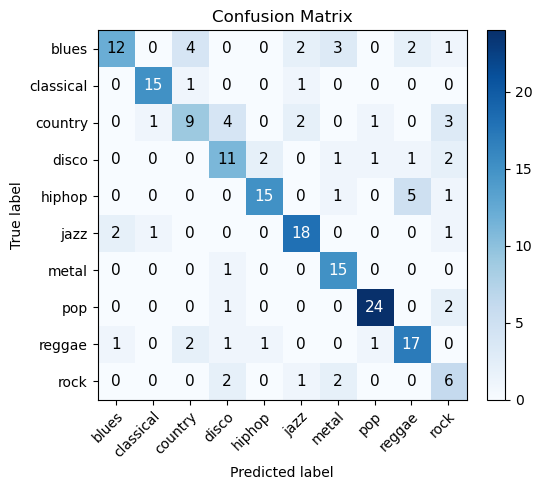

              precision    recall  f1-score   support

       blues       0.80      0.50      0.62        24
   classical       0.88      0.88      0.88        17
     country       0.56      0.45      0.50        20
       disco       0.55      0.61      0.58        18
      hiphop       0.83      0.68      0.75        22
        jazz       0.75      0.82      0.78        22
       metal       0.68      0.94      0.79        16
         pop       0.89      0.89      0.89        27
      reggae       0.68      0.74      0.71        23
        rock       0.38      0.55      0.44        11

    accuracy                           0.71       200
   macro avg       0.70      0.71      0.69       200
weighted avg       0.72      0.71      0.71       200



In [8]:
svmOvO.evaluate_accuracy(X_test, Y_test)
svmOvO.evaluate_models(X_test, Y_test)

true_labels = labels_encoding(Y_test, labels=class_names, pos_value=1, neg_value= 0)
pred_labels = labels_encoding(svmOvO(X_test), labels=class_names, pos_value=1, neg_value= 0)

confusion_matrix(true_labels, pred_labels, num_classes=10, class_names=class_names)

print(classification_report(Y_test, svmOvO(X_test), target_names=class_names))

### MLP Model

The first neural network we train is a **Multi-Layer Perceptron (MLP)** model using **MFCC features**.

The model has the following configuration:
- Input size: 40 (number of MFCC coefficients)
- Two hidden layers with sizes 128 and 64
- Output size: 10 (number of genre classes)
- ReLU activation function in hidden layers
- Softmax activation in the output layer
- Adam optimizer
- Cross-Entropy loss function

The labels from the train-test split should be one-hot encoded for the model.  
The overall performance on the training and test sets is evaluated using a learning curve and a confusion matrix.

In [9]:
# Convert string labels to integer class labels
Y_train_int = labels_to_numbers(Y_train)
Y_test_int = labels_to_numbers(Y_test)

# Then apply one-hot encoding
Y_train_encoded = one_hot_encoding(Y_train_int)
Y_test_encoded = one_hot_encoding(Y_test_int)

In [10]:
model = MLP(
    widths=config["layer_widths"], 
    optimizer= AdamOptimizer(learning_rate= config["optimizer_learning_rate"]),
    activation=config["activation"],
    output_activation=config["output_activation"],
    loss=config["loss"]
)

In [11]:
metrics_dict = {
    "accuracy": accuracy,
    "loss" : cross_entropy,
}

metrics_history = model.fit(X_train, Y_train_encoded, num_epochs= config["epochs"], batch_size= config["batch_size"], compute_metrics=True, metrics_dict=metrics_dict)

Train accuracy: 99.88% | Test accuracy: 74.50%


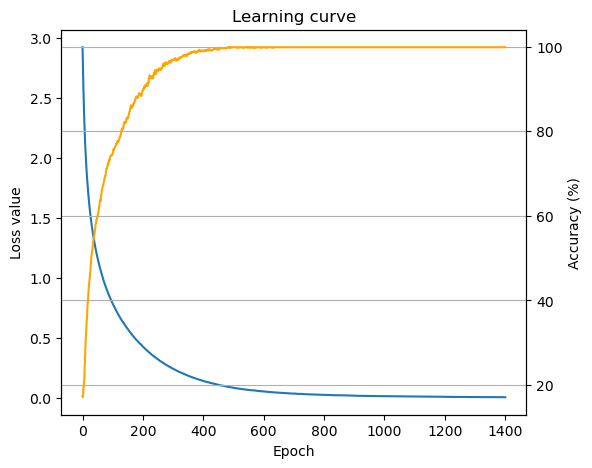

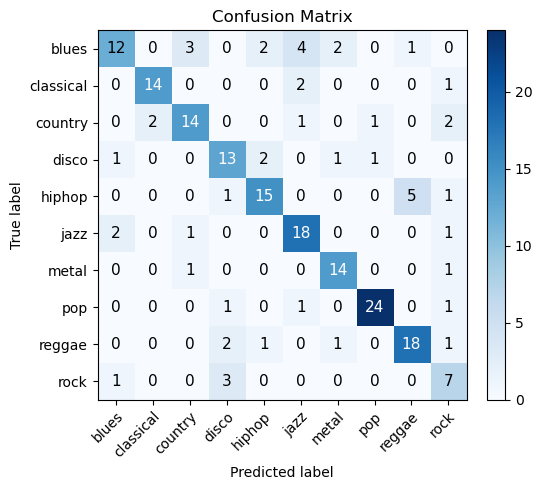

              precision    recall  f1-score   support

       blues       0.75      0.50      0.60        24
   classical       0.88      0.82      0.85        17
     country       0.74      0.70      0.72        20
       disco       0.65      0.72      0.68        18
      hiphop       0.75      0.68      0.71        22
        jazz       0.69      0.82      0.75        22
       metal       0.78      0.88      0.82        16
         pop       0.92      0.89      0.91        27
      reggae       0.75      0.78      0.77        23
        rock       0.47      0.64      0.54        11

    accuracy                           0.74       200
   macro avg       0.74      0.74      0.73       200
weighted avg       0.75      0.74      0.74       200



In [12]:
print(f"Train accuracy: {metrics_history['accuracy'][-1]:.2f}% | "
      f"Test accuracy: {accuracy(model.decision_function(X_test), Y_test_encoded):.2f}%")

plot_learning_curves(metrics_history)

# Convert true string labels to integer class indices
Y_test_int = labels_to_numbers(Y_test, class_names=class_names)

# Get predicted class indices from model
Y_pred_int = model(X_test)  # it returns integers

# Convert both to one-hot encoded
num_classes = len(class_names)
true_labels_onehot = one_hot_encoding(Y_test_int, num_classes)
pred_labels_onehot = one_hot_encoding(Y_pred_int, num_classes)

# Plot confusion matrix 
confusion_matrix(
    y_true=true_labels_onehot,
    y_pred=pred_labels_onehot,
    num_classes=num_classes,
    plot=True,
    class_names=class_names
)

print(classification_report(Y_test_int, Y_pred_int, target_names=class_names))

### CNN on Spectrograms Using PyTorch

We use spectrogram images provided in the GTZAN dataset to train a Convolutional Neural Network (CNN) using **PyTorch**.

To preprocess the data, we apply transformations using the `torchvision.transforms` module.

We decided to use two separate transformation pipelines:
- A more advanced one for training data, including resizing, random horizontal flips, and affine transformations, to introduce regularization and improve generalization.
- A simpler one for test data, applying only resizing and normalization.

This change was introduced in an attempt to improve accuracy, as the initial implementation used the same basic preprocessing for both sets. However, the improvement turned out to be marginal.

**Note:** One spectrogram from the *jazz* genre is missing, resulting in a total of 999 data points.

In [13]:
# Load dataset from folders
dataset, tranformer_train = loaders.load_spectrograms(config_cnn)


### Train-test split

The dataset is split into training and test sets using an **80/20** ratio.

In [14]:
train_dataset, test_dataset = train_test_split_images(dataset, config_cnn["training_data_fraction"], transform_train=tranformer_train)

train_loader, test_loader = loaders.get_data_loaders(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    batch_size=config_cnn["batch_size"],
    shuffle=True)

# Show class names
print("Classes:", dataset.classes)
print("Number of training samples:", len(train_dataset))
print("Number of validation samples:", len(test_dataset))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Number of training samples: 799
Number of validation samples: 200


### Train the CNN Model and Save Metrics

We train the **SimpleCNN** model — a custom class built on top of **PyTorch**'s CNN implementation, wrapped with helper methods for training, evaluation, and saving metrics.

The **SimpleCNN** model has the following configuration:

- **Convolutional layers:**
  - 3 convolutional blocks: *Conv2d → ReLU → MaxPool2d* with increasing channels: 32 → 64 → 128
- **Fully connected layers:**
  - Flattening layer
  - *Linear(128 × img_size//8 × img_size//8 → 128) → ReLU → Dropout*
  - *Linear(128 → 10)* for final class prediction
- **Other:**
  - Uses ReLU as activation
  - Dropout for regularization
  - Optimized using Adam
  - Trained with Cross-Entropy Loss

Metrics such as loss and accuracy are saved after each epoch for further analysis.

**Note:** Training for 25 epochs typically takes 5–10 minutes, depending on hardware (usually around 20 seconds per epoch).

In [15]:
model = SimpleCNN(config_cnn).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config_cnn["learning_rate"])

metrics_history = model.fit(train_loader, train_dataset, optimizer=optimizer, criterion=criterion, epochs=config_cnn["epochs"], device=device, test_loader=test_loader, test_dataset=test_dataset)

Overall accuracy: 13.50%
Epoch 1, Loss: 2.3220, Train Acc: 0.1227
Overall accuracy: 21.50%
Epoch 2, Loss: 2.1135, Train Acc: 0.1952
Overall accuracy: 26.00%
Epoch 3, Loss: 2.0151, Train Acc: 0.2753
Overall accuracy: 25.00%
Epoch 4, Loss: 2.0280, Train Acc: 0.2466
Overall accuracy: 31.00%
Epoch 5, Loss: 1.9055, Train Acc: 0.3054
Overall accuracy: 30.00%
Epoch 6, Loss: 1.8000, Train Acc: 0.3204
Overall accuracy: 33.50%
Epoch 7, Loss: 1.7457, Train Acc: 0.3692
Overall accuracy: 37.50%
Epoch 8, Loss: 1.6570, Train Acc: 0.4005
Overall accuracy: 39.50%
Epoch 9, Loss: 1.5972, Train Acc: 0.4118
Overall accuracy: 37.50%
Epoch 10, Loss: 1.5303, Train Acc: 0.4506
Overall accuracy: 44.00%
Epoch 11, Loss: 1.4571, Train Acc: 0.4706
Overall accuracy: 46.00%
Epoch 12, Loss: 1.4489, Train Acc: 0.4781
Overall accuracy: 45.50%
Epoch 13, Loss: 1.4411, Train Acc: 0.4693
Overall accuracy: 43.00%
Epoch 14, Loss: 1.4282, Train Acc: 0.4944
Overall accuracy: 48.50%
Epoch 15, Loss: 1.3868, Train Acc: 0.5019
Over

Overall accuracy: 58.00%


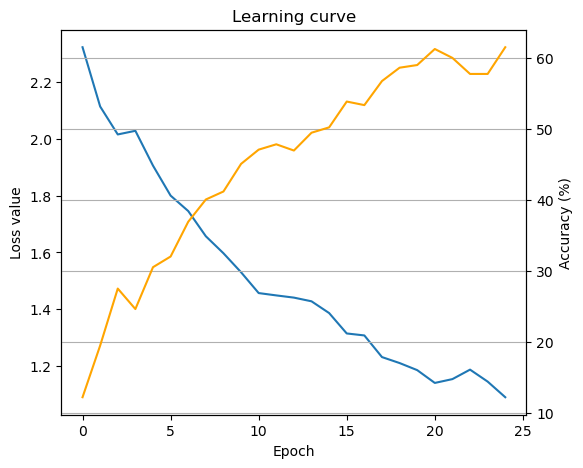

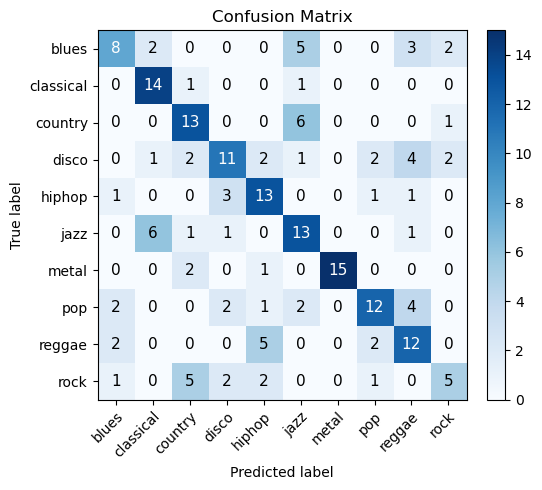

              precision    recall  f1-score   support

       blues       0.57      0.40      0.47        20
   classical       0.61      0.88      0.72        16
     country       0.54      0.65      0.59        20
       disco       0.58      0.44      0.50        25
      hiphop       0.54      0.68      0.60        19
        jazz       0.46      0.59      0.52        22
       metal       1.00      0.83      0.91        18
         pop       0.67      0.52      0.59        23
      reggae       0.48      0.57      0.52        21
        rock       0.50      0.31      0.38        16

    accuracy                           0.58       200
   macro avg       0.60      0.59      0.58       200
weighted avg       0.59      0.58      0.58       200



In [19]:
model.evaluate_accuracy(test_loader, test_dataset, device=device)

plot_learning_curves(metrics_history)

Y_true_int, Y_pred_int = model.get_true_and_pred_labels(test_loader, device=device)

# Convert to one-hot encoded
num_classes = config_cnn["num_classes"]  
true_labels_onehot = one_hot_encoding(Y_true_int, num_classes)
pred_labels_onehot = one_hot_encoding(Y_pred_int, num_classes)

# Plot confusion matrix
confusion_matrix(
    y_true=true_labels_onehot,
    y_pred=pred_labels_onehot,
    num_classes=num_classes,
    plot=True,
    class_names=dataset.classes  # or class_names if you've defined it elsewhere
)

print(classification_report(Y_true_int, Y_pred_int, target_names=class_names))

### Optional: save the model

You can optionally save the trained CNN model along with its configuration and training metrics for later reuse.

**Note:** The model will be saved as a .pth file and the training metrics as a .json file in the `pretrained_models/` directory.

In [17]:
# Uncomment the lines below to save the trained model:

#path = "pretrained_models/cnn_trained_100epochs"
#model.save_model(metrics_history, path, config=config_cnn)

### Load pretrained model

This section loads a previously trained CNN model from file along with its configuration and training metrics.

**Note:** If you haven't executed the earlier cells from the CNN section (the data loading and train-test split), make sure to run them first, as the model depends on those variables (test_loader, test_dataset, device).

In this notebook, we load the model trained for 100 epochs using separate transforms for training and validation `cnn_trained_100epochs_separate_transform`.

Overall accuracy: 64.50%


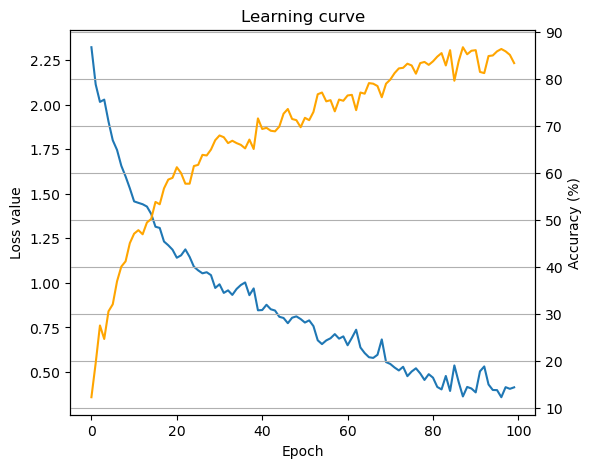

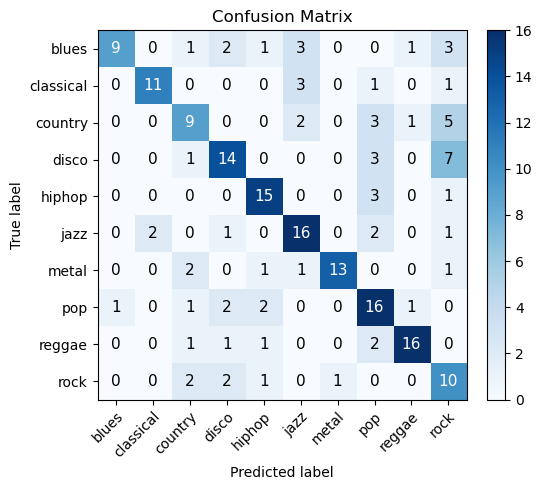

              precision    recall  f1-score   support

       blues       0.90      0.45      0.60        20
   classical       0.85      0.69      0.76        16
     country       0.53      0.45      0.49        20
       disco       0.64      0.56      0.60        25
      hiphop       0.71      0.79      0.75        19
        jazz       0.64      0.73      0.68        22
       metal       0.93      0.72      0.81        18
         pop       0.53      0.70      0.60        23
      reggae       0.84      0.76      0.80        21
        rock       0.34      0.62      0.44        16

    accuracy                           0.65       200
   macro avg       0.69      0.65      0.65       200
weighted avg       0.69      0.65      0.65       200



In [20]:
# Specify the path to the pretrained model
path = "pretrained_models/cnn_trained_100epochs_separate_transform"

loaded_model, loaded_metrics_history = load_SimpleCNN_model(path, device=device)

loaded_model.evaluate_accuracy(test_loader, test_dataset, device=device)

plot_learning_curves(loaded_metrics_history)

# Collect predictions and true labels on validation set
Y_true_int, Y_pred_int = loaded_model.get_true_and_pred_labels(test_loader, device=device)

# Convert to one-hot encoded
num_classes = config_cnn["num_classes"]  
true_labels_onehot = one_hot_encoding(Y_true_int, num_classes)
pred_labels_onehot = one_hot_encoding(Y_pred_int, num_classes)

# Plot confusion matrix
confusion_matrix(
    y_true=true_labels_onehot,
    y_pred=pred_labels_onehot,
    num_classes=num_classes,
    plot=True,
    class_names=dataset.classes
)

print(classification_report(Y_true_int, Y_pred_int, target_names=class_names))